**LIAR2 DATASET :** Fake news prediction

**Name:** Abhinav Tyagi

**Id**: 20028460


In [1]:
pip install umap-learn

In [2]:
# importing libraries
import numpy as np # Numerical and Data Handling
import pandas as pd
import re , nltk #natural language tool kit library
# Downloading NLTK resources needed for text processing
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('omw-1.4')
nltk.download('wordnet')
# HTML and Lemmatization
from bs4 import BeautifulSoup
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer  # Converts text to TF-IDF vectors
from sklearn import metrics # Model Evaluation
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC
import joblib
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import  LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import recall_score , confusion_matrix
from sklearn.ensemble import  RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package wordnet to /root/nltk_data...


      id  label  \
0  13847      5   
1  13411      1   
2  10882      0   
3  20697      4   
4   6095      2   

                                                                                                                    statement  \
0                                            90 percent of Americans "support universal background checks" for gun purchases.   
1                                                 Last year was one of the deadliest years ever for law enforcement officers.   
2                                                                Bernie Sanders's plan is "to raise your taxes to 90 percent.   
3  Voter ID is supported by an overwhelming majority of NYers, from all across the state, walks of life, & political parties.   
4                                              Says Barack Obama "robbed Medicare (of) $716 billion to pay for ... Obamacare.   

               date  \
0   October 2, 2017   
1      May 19, 2017   
2  October 28, 2015   
3  December 8, 202

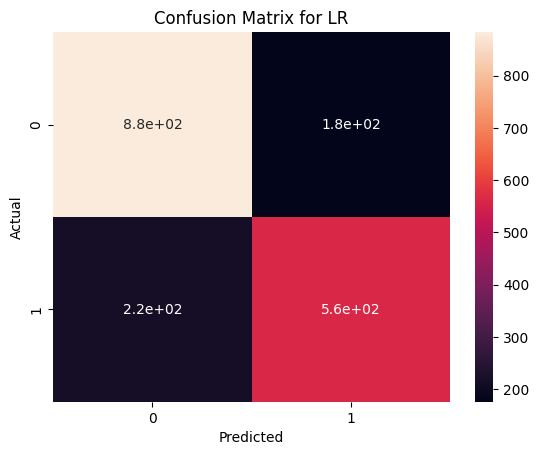


====NBC Cross Validation====
Iteration 1
Cross validation recall score :  0.7557840616966581
Iteration 2
Cross validation recall score :  0.7455012853470437
Iteration 3
Cross validation recall score :  0.7596401028277635
Iteration 4
Cross validation recall score :  0.7596401028277635
Iteration 5
Cross validation recall score :  0.7467866323907455
Iteration 6
Cross validation recall score :  0.7570694087403599
Iteration 7
Cross validation recall score :  0.7557840616966581
Iteration 8
Cross validation recall score :  0.7544987146529563
Iteration 9
Cross validation recall score :  0.7747747747747747
Iteration 10
Cross validation recall score :  0.7593307593307593
Cross Validation mean recall score :  0.7568809904285483
[[811 248]
 [187 590]]


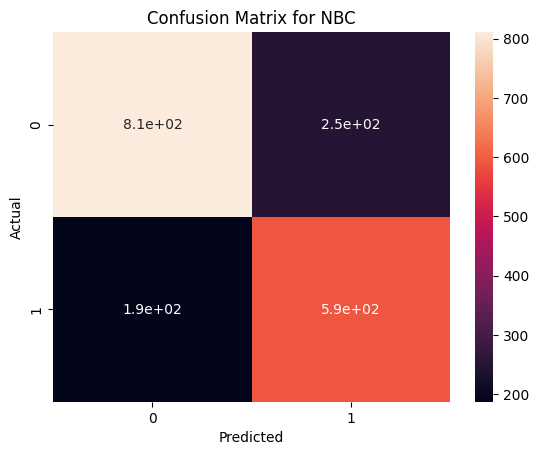


====SVC Cross Validation====
Iteration 1
Cross validation recall score :  0.7236503856041131
Iteration 2
Cross validation recall score :  0.7442159383033419
Iteration 3
Cross validation recall score :  0.7544987146529563
Iteration 4
Cross validation recall score :  0.7480719794344473
Iteration 5
Cross validation recall score :  0.7210796915167095
Iteration 6
Cross validation recall score :  0.7390745501285347
Iteration 7
Cross validation recall score :  0.7442159383033419
Iteration 8
Cross validation recall score :  0.7159383033419023
Iteration 9
Cross validation recall score :  0.7464607464607464
Iteration 10
Cross validation recall score :  0.7168597168597168
Cross Validation mean recall score :  0.7354065964605809
[[854 205]
 [220 557]]


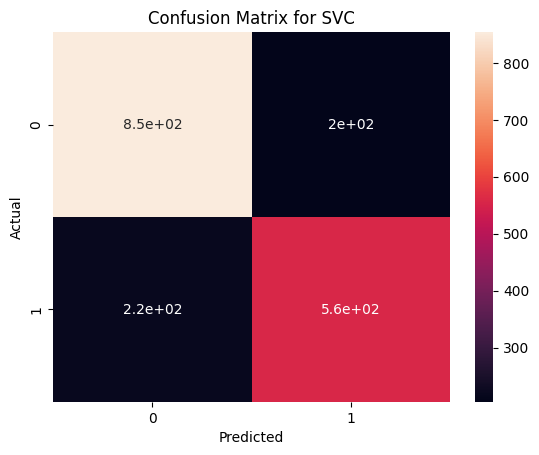


====RFC Cross Validation====
Iteration 1
Cross validation recall score :  0.7442159383033419
Iteration 2
Cross validation recall score :  0.7287917737789203
Iteration 3
Cross validation recall score :  0.7390745501285347
Iteration 4
Cross validation recall score :  0.699228791773779
Iteration 5
Cross validation recall score :  0.7146529562982005
Iteration 6
Cross validation recall score :  0.7365038560411311
Iteration 7
Cross validation recall score :  0.7532133676092545
Iteration 8
Cross validation recall score :  0.7262210796915167
Iteration 9
Cross validation recall score :  0.7361647361647362
Iteration 10
Cross validation recall score :  0.7168597168597168
Cross Validation mean recall score :  0.7294926766649132
[[883 176]
 [220 557]]


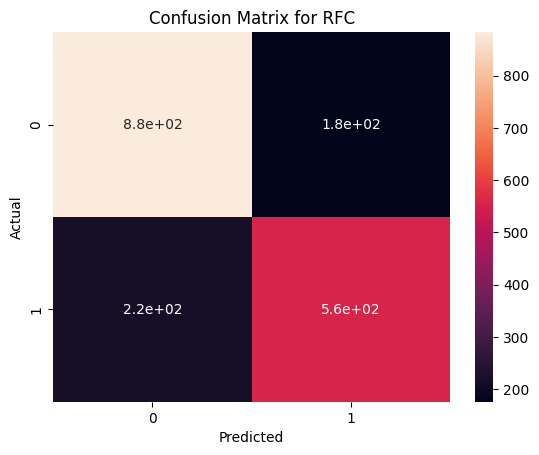

In [3]:
#reading the dataset
data = pd.read_csv('/content/train (1).csv')
# Display full content of cells and all columns
pd.set_option('display.max_colwidth',None)
pd.set_option('display.max_columns',None)
# Quick check of the first few rows
print(data.head())
# Checking the shape, info and summary stats
data.shape
data.info()
data.describe
data = data.fillna(" ") # Filling missing values with blank space
# Concatenating 'statement' and 'justification' for unified text analysis
data['full_statement'] =data['statement']+ " " +data['justification']

# Binary Classification Label Mapping
# 0, 1, 2 = Fake News → 0
# 3, 4, 5 = Real News → 1
data["New_label"] = data["label"].apply(lambda x: 0 if x in [0, 1, 2] else 1)

# Cleaner function for Preprocessing the Text
def cleaner(fake_news):
  soup = BeautifulSoup(fake_news,'lxml') # Remove HTML entities
  souped =soup.get_text()
  re1 = re.sub(r"(@|https://|www|http://|\\x)\S*"," ",souped)  # Remove URLs, handles
  re2 = re.sub('[^a-zA-Z]+',' ',re1)  # Keep only alphabetic characters
  token = nltk.word_tokenize(re2) # Tokenize text into words
  lower_case = [t.lower() for t in token] # Lowercase all tokens
  stop_words = set(stopwords.words('english'))  # Get English stopwords
  filtered_result = list(filter(lambda l:l  not in stop_words,lower_case)) # Remove stopwords

  wordnet_lemmatizer = WordNetLemmatizer()  # Lemmatize (verb form)
  lemmas = [wordnet_lemmatizer.lemmatize(t,'v') for t in filtered_result]
  return lemmas

# Apply cleaner function to all full statements
data['cleaned_statements'] = data.full_statement.apply(cleaner)
data = data[data['cleaned_statements'].map(len)>0] # Remove rows where cleaned statements are empty
print("Printing first 5 rows of dataframe showing original and cleaned statements") # Show cleaned vs. original text
print(data[['full_statement','cleaned_statements']].head())

# Dropping unneeded columns to simplify model input
data.drop(['id','full_statement','date','speaker','subject','speaker_description','state_info','true_counts','mostly_true_counts','half_true_counts','mostly_false_counts','false_counts','pants_on_fire_counts','context'],axis = 1,inplace = True)
data['cleaned_statement'] = [' '.join(row) for row in data['cleaned_statements'].values] # Joining tokens back into cleaned text strings

# Assigning final input and target variable
df= data['cleaned_statement']
Y = data['New_label']

#TF-IDF Vectorization
tfidf = TfidfVectorizer(min_df= 0.0016, ngram_range=(1,3))
tfidf.fit(df)
data_tfidf = tfidf.transform(df)

# Save vocabulary to a CSV
pd.DataFrame(pd.Series(tfidf.get_feature_names_out())).to_csv('news_vocalbulary.csv', header = False, index = False)

# printing shape of Tfidf matrix
print("Shape of TFIDF matrix shape : ",data_tfidf.shape)

# Model Setup
model = {
    'LR': LogisticRegression(max_iter=1000, random_state=1),
    'NBC': MultinomialNB(),
    'SVC' :LinearSVC(), # Linear kernel, C=1 default
    'RFC': RandomForestClassifier(n_estimators=100, random_state=1)
}
# Stratified K-Fold Cross-Validation (10 Folds)
kf = StratifiedKFold(n_splits= 10, shuffle = True, random_state = 1)
for name, model in model.items(): # Run each model with cross-validation
 print(f"\n===={name} Cross Validation====")
 scores = []
 iteration = 0
 for train_index, test_index in kf.split(data_tfidf,Y): # Perform 10-fold cross-validation
   iteration +=1
   print("Iteration", iteration)
   X_train, Y_train = data_tfidf[train_index],Y[train_index]  # Split the data into training and test sets for this fold
   X_test, Y_test = data_tfidf[test_index],Y[test_index]
   model.fit(X_train,Y_train)   # Train the model on the current fold's training data
   Y_pred = model.predict(X_test)
   cf_mat =confusion_matrix(Y_test,Y_pred)
   score = metrics.recall_score(Y_test,Y_pred)    # Evaluate using Recall — focusing on catching fake news (minimize false negatives)
   print("Cross validation recall score : ",score)
   scores.append(score)
 mean_recall = np.mean(scores)   # Calculate and print the average recall across all 10 folds
 print("Cross Validation mean recall score : ",mean_recall)
 print(cf_mat) #Confusion matrix
 sns.heatmap(cf_mat,annot = True)
 plt.xlabel('Predicted')
 plt.ylabel('Actual')
 plt.title(f'Confusion Matrix for {name}')
 plt.show()

In [4]:
# Import necessary visualization and dimensionality reduction libraries
from umap import UMAP
import plotly.figure_factory as ff
import plotly.graph_objs as go
from sklearn.linear_model import LogisticRegression

# Reduce TF-IDF features
# Initialize UMAP with specific parameters
# n_components = 2 → reduce to 2D for visualization
# n_neighbors = 250 → higher value captures more global structure
# min_dist = 0.1 → controls the spacing of points; lower means tighter clusters
umap_model = UMAP(n_components=2, n_neighbors = 100, min_dist = 0.01)
x_umap = umap_model.fit_transform(data_tfidf) # Fit UMAP on the TF-IDF feature matrix and transform it into 2D
statements = data['statement'] # Retrieve original text and labels for hover text in the plot
label = data['label']

# Create a 2D scatter plot using Plotly
# Points are colored using the binary label Y (0 = Fake, 1 = Real)
dataset_umap = [go.Scatter(x =x_umap[:,0],y = x_umap[:,1], mode = 'markers',
                          marker = dict(color = Y, colorscale = 'Rainbow', opacity = 0.5),
                           text = [f'statments: {a}<br>label: {b}' for a, b, in zip(statements,label)],
                           hoverinfo = 'text')]
# Define layout settings for the UMAP plot
layout_umap = go.Layout(title = "UMAP Dimensionality Reduction", width = 1400, height = 1400,
                        xaxis = dict(title = "First Dimension"),
                        yaxis = dict(title = "Second Dimension"))
fig_umap = go.Figure(data = dataset_umap,layout = layout_umap)
fig_umap.show()

# Testing some random samples

In [5]:
# Save the best performing model (MultinomialNB)
joblib.dump(model, 'multinomial_nb_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Model and TF-IDF vectorizer saved.")

# Load the saved model and vectorizer
loaded_model = joblib.load('multinomial_nb_model.pkl')
loaded_tfidf = joblib.load('tfidf_vectorizer.pkl')

# --- Placeholder for predicting on new data ---
# Example of new data (replace with your actual new data)
new_data = ["Government announces plan to abolish elections and appoint leaders directly through AI algorithms starting next year.", "New study shows that drinking bleach can cure COVID-19 within 24 hours, scientists confirm."]

# Preprocess the new data using the loaded TF-IDF vectorizer
new_data_tfidf = loaded_tfidf.transform(new_data)

# Make predictions using the loaded model
predictions = loaded_model.predict(new_data_tfidf)

print("\nPredictions on new data:")
for statement, prediction in zip(new_data, predictions):
  label = "Real News" if prediction == 1 else "Fake News"
  print(f"Statement: '{statement}' -> Predicted Label: {label}")

Model and TF-IDF vectorizer saved.

Predictions on new data:
Statement: 'Government announces plan to abolish elections and appoint leaders directly through AI algorithms starting next year.' -> Predicted Label: Fake News
Statement: 'New study shows that drinking bleach can cure COVID-19 within 24 hours, scientists confirm.' -> Predicted Label: Fake News
